<a href="https://colab.research.google.com/github/2501407/Statistical-Interpretation-and-Exploratory-Data-Analysis-/blob/merge/2501407_Bharat_Gautam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
dataframe = pd.read_csv('/content/drive/MyDrive/Level5/AI/Assignment1/Human_Development_Index_Dataset.csv', encoding='ISO-8859-1')

Mounted at /content/drive


# **Problem 1 Basic Data Exploration & Trend Visualization**

In [2]:
print(dataframe.shape)
print(dataframe.columns)

(6798, 30)
Index(['Unnamed: 0', 'iso3', 'country', 'year', 'hdi', 'life_expectancy',
       'pop_millions', 'hdi_f', 'hdi_m', 'life_expec_f', 'life_expec_m',
       'expec_yr_school', 'expec_yr_school_f', 'expec_yr_school_m',
       'mean_yr_school', 'mean_yr_school_f', 'mean_yr_school_m',
       'gross_inc_percap', 'gross_inc_percap_f', 'gross_inc_percap_m',
       'gender_development', 'gender_inequality', 'secondary_education_f_%',
       'secondary_education_m_%', 'seats_in_parliament_f_%',
       'seats_in_parliament_m_%', 'labour_participation_f_%',
       'labour_participation_m_%', 'co2_emission_tons',
       'mat_footprint_percap_tons'],
      dtype='object')


# Problem - 1A - Single Year HDI Exploration (Latest Year: 2022)

In [3]:
#1. Extract Latest Year:
#Identify unique years in the dataset.
unique_years = dataframe['year'].unique().tolist()
print("Unique years:", sorted(unique_years))

Unique years: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


In [4]:
#Filter the dataset to include only observations from the year 2022.
#Save the filtered dataframe as hdi 2022 df
hdi_2022_df = dataframe[dataframe['year'] == 2022].copy()
#Count the number of rows and columns.
rows, cols = hdi_2022_df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 206
Number of columns: 30


In [5]:
#2 Data Exploration:
#Display the first 10 rows of the 2022 dataset.
hdi_2022_df.head(10)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [6]:
#List all column names and their data types.
print("Column names and data types:")
hdi_2022_df.dtypes

Column names and data types:


,0
Unnamed: 0,int64
iso3,object
country,object
year,int64
hdi,float64
life_expectancy,float64
pop_millions,float64
hdi_f,float64
hdi_m,float64
life_expec_f,float64


In [9]:
#Missing Values & Data Cleaning:
#Missing values per column:
missing_counts = hdi_2022_df.isnull().sum()
missing_percent = (missing_counts / len(hdi_2022_df)) * 100

print("Missing values per column:")
for col in hdi_2022_df.columns:
    if missing_counts[col] > 0:
        print(f"{col}: {missing_counts[col]} missing ({missing_percent[col]:.2f}%)")

# Total missing
print(f"\nTotal missing values in dataset: {missing_counts.sum()}")

Missing values per column:
hdi: 2 missing (0.97%)
hdi_f: 13 missing (6.31%)
hdi_m: 13 missing (6.31%)
expec_yr_school: 1 missing (0.49%)
expec_yr_school_f: 1 missing (0.49%)
expec_yr_school_m: 1 missing (0.49%)
mean_yr_school: 2 missing (0.97%)
mean_yr_school_f: 2 missing (0.97%)
mean_yr_school_m: 2 missing (0.97%)
gross_inc_percap: 2 missing (0.97%)
gross_inc_percap_f: 13 missing (6.31%)
gross_inc_percap_m: 13 missing (6.31%)
gender_development: 13 missing (6.31%)
gender_inequality: 29 missing (14.08%)
secondary_education_f_%: 17 missing (8.25%)
secondary_education_m_%: 17 missing (8.25%)
seats_in_parliament_f_%: 2 missing (0.97%)
seats_in_parliament_m_%: 2 missing (0.97%)
labour_participation_f_%: 12 missing (5.83%)
labour_participation_m_%: 12 missing (5.83%)
co2_emission_tons: 2 missing (0.97%)
mat_footprint_percap_tons: 41 missing (19.90%)

Total missing values in dataset: 212


In [10]:
#inconsistent or misspelled country names,
if 'country' in hdi_2022_df.columns:
  total_countries = hdi_2022_df['country']
  print(f"Total countries:{len(total_countries)}")
  unique_countries = total_countries.unique()
  print(f"Number of unique countries: {len(unique_countries)}")
  # Look for potential duplicates with slight spelling variations
  print("\nSample country names:")
  country_counts = hdi_2022_df['country'].value_counts()
  print(f"Number of unique countries: {len(country_counts)}")
  print("\nCounts of each country:")
  print(f"{country_counts.head(20)}")

Total countries:206
Number of unique countries: 206

Sample country names:
Number of unique countries: 206

Counts of each country:
country
Afghanistan            1
Albania                1
Algeria                1
Andorra                1
Angola                 1
Antigua and Barbuda    1
Argentina              1
Armenia                1
Australia              1
Austria                1
Azerbaijan             1
Bahamas                1
Bahrain                1
Bangladesh             1
Barbados               1
Belarus                1
Belgium                1
Belize                 1
Benin                  1
Bhutan                 1
Name: count, dtype: int64


In [11]:
#duplicate rows
print(hdi_2022_df.duplicated().sum())

0


In [25]:
#numeric columns stored as text
text_columns = []
for col in hdi_2022_df.columns:
    if hdi_2022_df[col].dtype == 'object':
        # Try to detect if it should be numeric
        try:
            pd.to_numeric(hdi_2022_df[col])
            text_columns.append(col)
        except:
            pass

print(f"Potential numeric columns stored as text: {text_columns}")
hdi_2022_df['hdi'].unique()

Potential numeric columns stored as text: []


In [26]:
#special characters indicating missing data
special_chars = ["–", "—", "..", "N/A", "n/a", "NA", "na", "nan", "-", "?"]
for char in special_chars:
    for col in hdi_2022_df.columns:
        if hdi_2022_df[col].dtype == 'object':
            count = (hdi_2022_df[col] == char).sum()
            if count > 0:
                print(f"Found '{char}' in column {col}: {count} times")

In [14]:
#Convert data types
for col in text_columns:
    hdi_2022_df[col] = pd.to_numeric(hdi_2022_df[col])
    print(f"Converted {col} to numeric")

In [15]:
#Handle special characters (convert to NaN)
for col in hdi_2022_df.columns:
    if hdi_2022_df[col].dtype == 'object':
        for char in special_chars:
            hdi_2022_df[col] = hdi_2022_df[col].replace(char, np.nan)

In [16]:
#Remove duplicate rows by country and year
initial_rows = len(hdi_2022_df)
# Remove rows with same country AND year
hdi_2022_df = hdi_2022_df.drop_duplicates(subset=['country', 'year'])
final_rows = len(hdi_2022_df)
print(f"Removed {initial_rows - final_rows} duplicate rows")

Removed 0 duplicate rows


In [17]:
#Handle missing values
print("Removing all null values")
hdi_2022_df.dropna(inplace=True)
print(f"After dropping nulls:")
print(f"Shape: {hdi_2022_df.shape}")

Removing all null values
After dropping nulls:
Shape: (158, 30)


In [28]:
mean_hdi = hdi_2022_df['hdi'].mean()
median_hdi = hdi_2022_df['hdi'].median()
std_hdi = hdi_2022_df['hdi'].std()
print("Mean, Median, and Standard Deviation of HDI for the year 2022:")
print(f"Mean: {mean_hdi},\n Median: {median_hdi},\n Standard Deviation: {std_hdi}")

Mean, Median, and Standard Deviation of HDI for the year 2022:
Mean: 0.7314177215189873,
 Median: 0.759,
 Standard Deviation: 0.1571854442617671


In [29]:
# idxmax() gives the maximum HDI
highest_hdi_country = hdi_2022_df.loc[
    hdi_2022_df['hdi'].idxmax(), ['country', 'hdi']
]
print(highest_hdi_country)

country    Switzerland
hdi              0.967
Name: 5609, dtype: object


In [30]:
# idxmin() gives the minimum HDI index
lowest_hdi_country = hdi_2022_df.loc[
    hdi_2022_df['hdi'].idxmin(), ['country', 'hdi']
]
print(lowest_hdi_country)

country    Somalia
hdi           0.38
Name: 5345, dtype: object


In [31]:
#Filtering and Sorting:
## Sort filtered dataset by 'gross_inc_percap' in descending order
high_hdi_df = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]
high_hdi_sorted_df = high_hdi_df.sort_values(
    by='gross_inc_percap',
    ascending=False
)
print(high_hdi_sorted_df[['country', 'hdi', 'gross_inc_percap']].head(10))

                   country    hdi  gross_inc_percap
4718                 Qatar  0.875       95944.37754
5213             Singapore  0.949       88761.14559
2705               Ireland  0.950       87467.51391
3398            Luxembourg  0.927       78554.23640
6104  United Arab Emirates  0.937       74103.71494
5609           Switzerland  0.967       69432.78669
4322                Norway  0.966       69189.76165
6170         United States  0.927       65564.93798
1550               Denmark  0.952       62018.95694
824      Brunei Darussalam  0.823       59245.63485


In [32]:
#Adding HDI Category Column:
def classify_hdi(hdi):
    if hdi < 0.550:
        return "Low"
    elif 0.550 <= hdi <= 0.699:
        return "Medium"
    elif 0.700 <= hdi <= 0.799:
        return "High"
    else:
        return "Very High"
# Apply the function to the 'hdi' column and create a new column 'HDI Category'
hdi_2022_df['HDI Category'] = hdi_2022_df['hdi'].apply(classify_hdi)
hdi_2022_df.head()

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons,HDI Category
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809,Low
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367,High
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199,High
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568,Medium
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512,Very High


In [33]:
#verify that all countries are classified correctly,
hdi_value_count = hdi_2022_df['HDI Category'].value_counts()
print(hdi_value_count)
print(hdi_value_count.sum())

HDI Category
Very High    60
High         40
Medium       30
Low          28
Name: count, dtype: int64
158


In [34]:
hdi_2022_df.shape

(158, 31)

In [35]:
# Save the updated dataset to a new CSV file
hdi_2022_df.to_csv("HDI_2022_category.csv", index=False)

# **Problem - 1B - HDI Visualization and Trend Analysis (2020 – 2022)**
**multi-year HDI patterns (2020, 2021, and 2022)**

In [36]:
hdi_problem1B_df =dataframe[dataframe['year'].isin([2020, 2021, 2022])]
hdi_problem1B_df.to_csv("HDI_problem1B.csv", index=False)

In [37]:
missing_values = hdi_problem1B_df[['hdi', 'country', 'year']].isnull().sum()
print(missing_values)

hdi        8
country    0
year       0
dtype: int64


In [38]:
#inconsistent or misspelled country names,
if 'country' in hdi_problem1B_df.columns:
  total_countries = hdi_problem1B_df['country']
  print(f"Total countries:{len(total_countries)}")
  unique_countries = total_countries.unique()
  print(f"Number of unique countries: {len(unique_countries)}")
  # Look for potential duplicates with slight spelling variations
  print("\nSample country names:")
  country_counts = hdi_problem1B_df['country'].value_counts()
  print(f"{country_counts.value_counts().unique()}")
  print(f"Number of unique countries: {len(country_counts)}")
  print("\nCounts of each country:")
  print(f"{country_counts.head(20)}")

Total countries:618
Number of unique countries: 206

Sample country names:
[206]
Number of unique countries: 206

Counts of each country:
country
Afghanistan            3
Albania                3
Algeria                3
Andorra                3
Angola                 3
Antigua and Barbuda    3
Argentina              3
Armenia                3
Australia              3
Austria                3
Azerbaijan             3
Bahamas                3
Bahrain                3
Bangladesh             3
Barbados               3
Belarus                3
Belgium                3
Belize                 3
Benin                  3
Bhutan                 3
Name: count, dtype: int64


In [39]:
#duplicate rows
print(hdi_problem1B_df.duplicated().sum())

0


In [40]:
#special characters indicating missing data
special_chars = ["–", "—", "..", "N/A", "n/a", "NA", "na", "-", "?"]
for char in special_chars:
    for col in hdi_problem1B_df.columns:
        if hdi_problem1B_df[col].dtype == 'object':
            count = (hdi_problem1B_df[col] == char).sum()
            if count > 0:
                print(f"Found '{char}' in column {col}: {count} times")

In [41]:
#Handle numeric columns stored as text
text_columns = []
for col in hdi_problem1B_df.columns:
    if hdi_problem1B_df[col].dtype == 'object':
        # Try to detect if it should be numeric
        try:
            pd.to_numeric(hdi_problem1B_df[col])
            text_columns.append(col)
        except:
            pass

print(f"Potential numeric columns stored as text: {text_columns}")

Potential numeric columns stored as text: []


In [43]:
#Handle missing values
# Remove rows where 'hdi', 'country', or 'year' has missing values (NaN)
hdi_problem1B_df.dropna(
    subset=['hdi', 'country', 'year'],
    )
print(f"After dropping nulls:")
print(f"Shape: {hdi_problem1B_df.shape}")

After dropping nulls:
Shape: (610, 30)


In [44]:
#Convert data types
for col in text_columns:
    hdi_problem1B_df[col] = pd.to_numeric(hdi_problem1B_df[col])
    print(f"Converted {col} to numeric")

In [45]:
#Remove duplicate rows by country and year
print("Before:", hdi_problem1B_df.shape)
initial_rows = len(hdi_problem1B_df)
# Remove rows with same country AND year
hdi_problem1B_df = hdi_problem1B_df.drop_duplicates(subset=['country', 'year'])
final_rows = len(hdi_problem1B_df)
print(f"Removed {initial_rows - final_rows} duplicate rows")
print("After:", hdi_problem1B_df.shape)

Before: (610, 30)
Removed 0 duplicate rows
After: (610, 30)


In [46]:
#ensuring consistent naming conventions for countries
#for year handling numeric columns stored as text does the work
hdi_problem1B_df['country'] = (
    hdi_problem1B_df['country']
    .str.strip()
    .str.title()
)

**Visualization Tasks:**

In [47]:
#Line Chart — HDI Trend (Country-Level):
selected_countries = [
    'Australia',
    'Saudi Arabia',
    'United States',
    'Japan',
    'Israel',
]

In [48]:
# This creates a new dataset with data for only those specific countries
country_hdi_df = hdi_problem1B_df[
    hdi_problem1B_df['country'].isin(selected_countries)
]

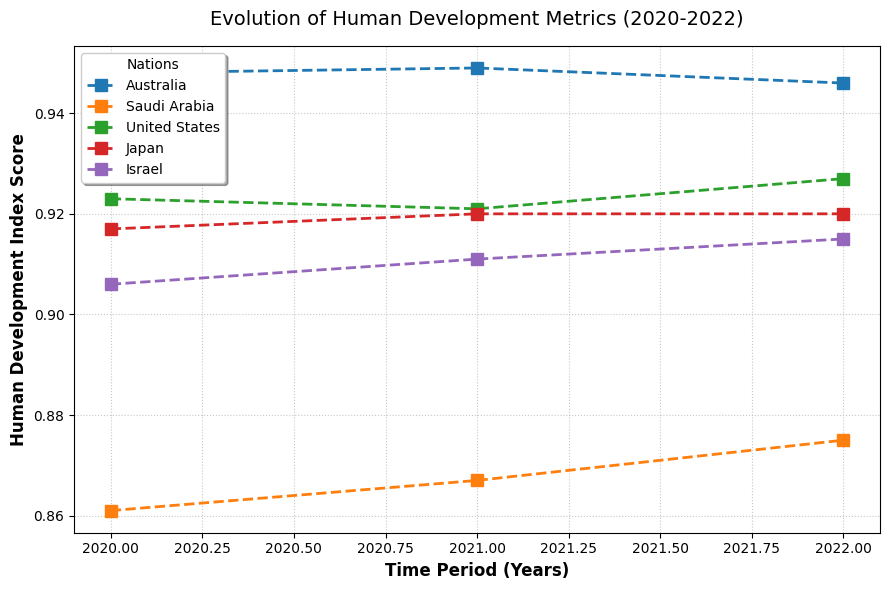

In [49]:
fig, ax = plt.subplots(figsize=(9, 6))

# Process each selected country
for country_name in selected_countries:
    # Filter data for the current country
    filtered_data = country_hdi_df[country_hdi_df['country'] == country_name]

    # Create line plot with markers
    ax.plot(
        filtered_data['year'],
        filtered_data['hdi'],
        marker='s',
        linestyle='--',
        linewidth=2,
        markersize=8,
        label=country_name
    )

# Customize labels and title
ax.set_xlabel("Time Period (Years)", fontsize=12, fontweight='bold')
ax.set_ylabel("Human Development Index Score", fontsize=12, fontweight='bold')
ax.set_title("Evolution of Human Development Metrics (2020-2022)",
             fontsize=14, pad=15)

ax.legend(title="Nations", frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [50]:
# Group the dataset by 'year' and calculate the average HDI for each year
year_avg = hdi_problem1B_df.groupby('year')['hdi'].mean().reset_index()
print(year_avg)

   year       hdi
0  2020  0.720897
1  2021  0.720039
2  2022  0.722887


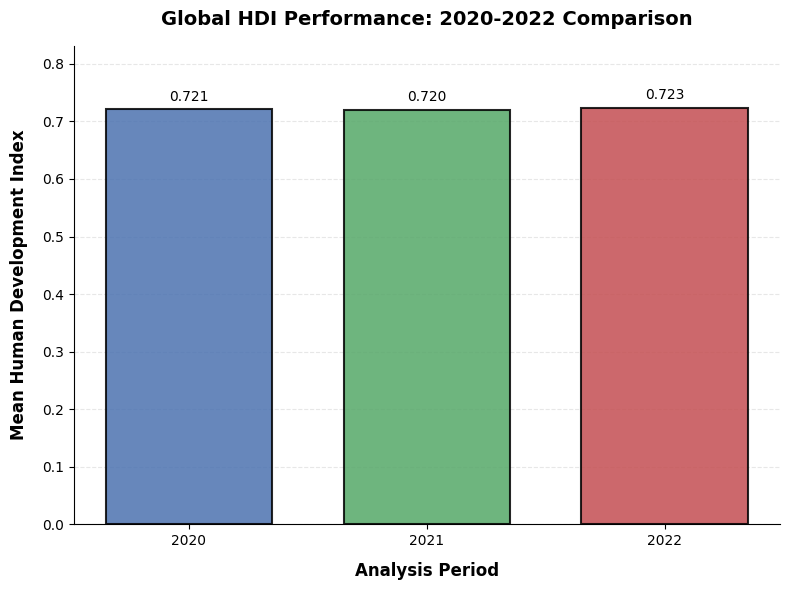

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

bar_colors = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.bar(
    year_avg['year'].astype(str),  # Convert years to strings for categorical x-axis
    year_avg['hdi'],
    color=bar_colors,
    edgecolor='black',
    linewidth=1.5,
    width=0.7,
    alpha=0.85
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.01,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Customize labels with better formatting
ax.set_xlabel("Analysis Period", fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel("Mean Human Development Index", fontsize=12, fontweight='semibold', labelpad=10)
ax.set_title("Global HDI Performance: 2020-2022 Comparison",
             fontsize=14, fontweight='bold', pad=15)

# Adjust y-axis limits with some padding
ax.set_ylim(0, max(year_avg['hdi']) * 1.15)

ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

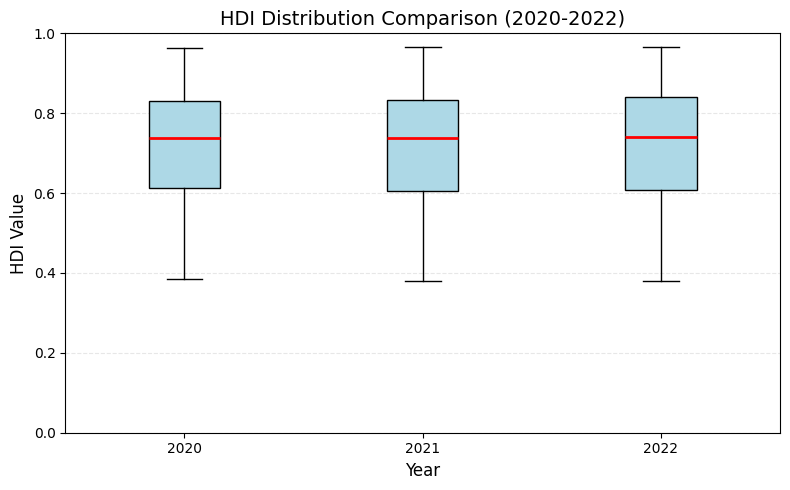

In [53]:
# Create a clean, simple boxplot
plt.figure(figsize=(8, 5))

# Prepare data for each year
data_2020 = hdi_problem1B_df[hdi_problem1B_df['year'] == 2020]['hdi']
data_2021 = hdi_problem1B_df[hdi_problem1B_df['year'] == 2021]['hdi']
data_2022 = hdi_problem1B_df[hdi_problem1B_df['year'] == 2022]['hdi']

# Combine data into a list
yearly_data = [data_2020, data_2021, data_2022]

# Create the boxplot with some customization
plt.boxplot(
    yearly_data,
    tick_labels=['2020', '2021', '2022'],
    patch_artist=True,  # Allows us to fill boxes with color
    boxprops=dict(facecolor='lightblue'),  # Fill boxes with light blue
    medianprops=dict(color='red', linewidth=2),  # Red median line
)

# Customize labels and title
plt.xlabel("Year", fontsize=12)
plt.ylabel("HDI Value", fontsize=12)
plt.title("HDI Distribution Comparison (2020-2022)", fontsize=14)

# Add horizontal grid for easier reading
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Set y-axis limits
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

**HDI Distribution (2020-2022)**

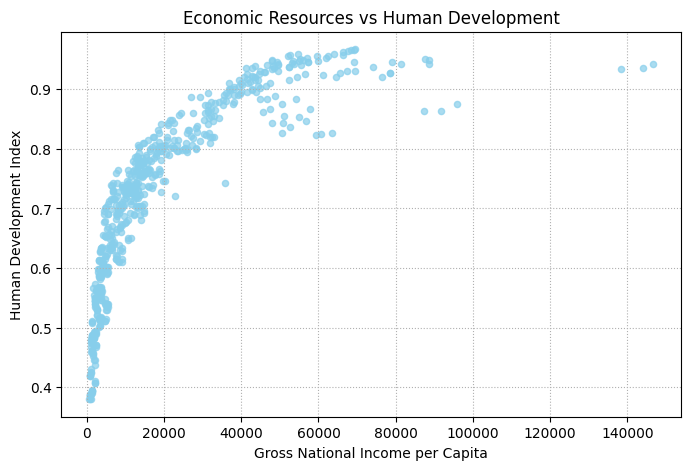

In [54]:
# Convert data to numeric
hdi_problem1B_df['gross_inc_percap'] = pd.to_numeric(
    hdi_problem1B_df['gross_inc_percap'],
    errors='coerce'
)

plt.figure(figsize=(8, 5))

plt.scatter(
    hdi_problem1B_df['gross_inc_percap'],
    hdi_problem1B_df['hdi'],
    color='skyblue',
    alpha=0.7,
    s=20
)

plt.xlabel("Gross National Income per Capita")
plt.ylabel("Human Development Index")
plt.title("Economic Resources vs Human Development")
plt.grid(True, linestyle=':')
plt.show()

# Problem 2 Advanced HDI Exploration

In [55]:
south_asia_countries = [
    "Afghanistan", "Bangladesh", "Bhutan", "India",
    "Maldives", "Nepal", "Pakistan", "Sri Lanka"
]

In [56]:
hdi_southasia_df = hdi_problem1B_df[
    hdi_problem1B_df['country'].isin(south_asia_countries)
]

In [57]:
hdi_southasia_df.to_csv("HDI_SouthAsia.csv", index=False)

In [61]:
hdi_southasia_df.loc[:, 'life_expectancy'] = pd.to_numeric(hdi_southasia_df['life_expectancy'], errors='coerce')
hdi_southasia_df.loc[:, 'gross_inc_percap'] = pd.to_numeric(hdi_southasia_df['gross_inc_percap'], errors='coerce')

In [62]:
hdi_southasia_df.dropna(
    subset=['life_expectancy', 'gross_inc_percap']
)

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
30,31.0,AFG,Afghanistan,2020.0,0.488,62.575,38.972231,0.381373,0.548741,65.432,...,0.695,0.674,6.092345,15.945160,27.215190,72.784810,16.50,66.84,0.305040,1.5554
31,32.0,AFG,Afghanistan,2021.0,0.473,61.982,40.099462,0.379129,0.528559,65.279,...,0.717,0.653,6.395730,14.865710,27.215190,72.784810,23.33,77.09,0.306318,1.2351
32,33.0,AFG,Afghanistan,2022.0,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
459,460.0,BGD,Bangladesh,2020.0,0.657,71.968,167.420951,0.619431,0.682912,73.957,...,0.907,0.502,43.659868,50.507937,20.916905,79.083095,38.74,81.27,0.559159,4.5993
460,461.0,BGD,Bangladesh,2021.0,0.662,72.381,169.356251,0.624949,0.687950,74.267,...,0.908,0.500,43.659868,50.507937,20.857143,79.142857,39.15,81.39,0.583153,4.6834
461,462.0,BGD,Bangladesh,2022.0,0.670,73.698,171.186373,0.634605,0.694223,76.012,...,0.914,0.498,43.659868,50.507937,20.857143,79.142857,39.15,81.39,0.583153,4.6457
657,658.0,BTN,Bhutan,2020.0,0.675,71.609,0.772506,0.667533,0.681309,73.536,...,0.980,0.326,26.681771,34.252853,15.277778,84.722222,63.52,72.51,1.190619,27.7915
658,659.0,BTN,Bhutan,2021.0,0.677,71.815,0.777486,0.671331,0.682830,73.773,...,0.983,0.318,26.681771,34.252853,16.666667,83.333333,65.30,73.10,1.366198,24.2373
659,660.0,BTN,Bhutan,2022.0,0.681,72.229,0.782455,0.669680,0.690410,74.152,...,0.970,0.334,26.681771,34.252853,15.714286,84.285714,53.48,73.45,1.366198,24.7398
2571,2572.0,IND,India,2020.0,0.638,70.150,1396.387127,0.569477,0.679697,71.824,...,0.838,0.453,40.073738,58.762402,13.392857,86.607143,26.17,74.25,1.734155,4.4451


In [63]:
# Aggregate by country (mean across all years)
southasia_country_df = (
    hdi_southasia_df
    .groupby('country', as_index=False)
    .agg({
        'life_expectancy': 'mean',
        'gross_inc_percap': 'mean',
        'hdi': 'mean'
    })
)

In [64]:
# New 'Composite Score' for South Asian countries
# 30% of life expectancy + 30% of gross income per capita
southasia_country_df['Composite Score'] = (
    0.30 * southasia_country_df['life_expectancy'] +
    0.30 * southasia_country_df['gross_inc_percap']
)

southasia_country_df['Composite Rank'] = (
    southasia_country_df['Composite Score']
    .rank(ascending=False, method='dense')
)

composite_rank_df = southasia_country_df.sort_values('Composite Rank')

In [65]:
top5_composite = composite_rank_df.head(5)
print(top5_composite[['country', 'Composite Score', 'hdi']])

      country  Composite Score       hdi
4    Maldives      4827.657597  0.750667
7   Sri Lanka      3767.752918  0.780000
2      Bhutan      3097.787317  0.677667
3       India      1978.776712  0.638333
1  Bangladesh      1877.251264  0.663000


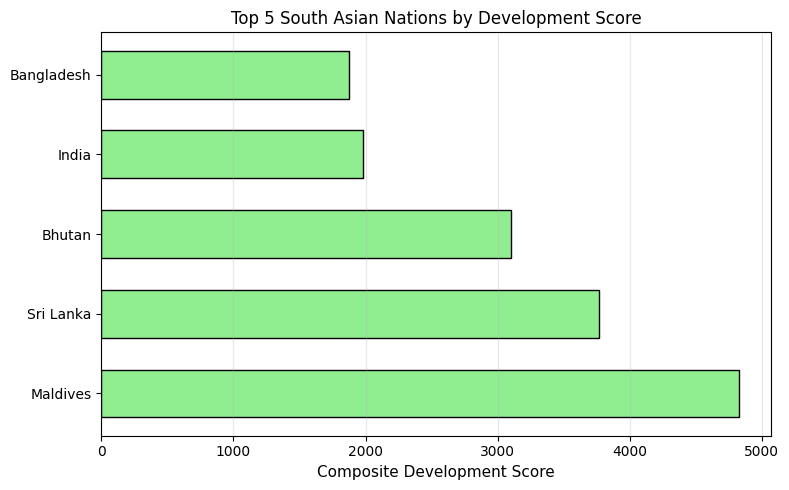

In [66]:
plt.figure(figsize=(8, 5))

plt.barh(
    top5_composite['country'],
    top5_composite['Composite Score'],
    color='lightgreen',
    height=0.6,
    edgecolor='black'
)

plt.xlabel("Composite Development Score", fontsize=11)
plt.ylabel("")
plt.title("Top 5 South Asian Nations by Development Score")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [67]:
hdi_rank_df = hdi_southasia_df.sort_values(by='hdi',ascending=False)
print(hdi_rank_df[['country', 'hdi']])

                      country    hdi
5476                Sri Lanka  0.783
5477                Sri Lanka  0.780
5475                Sri Lanka  0.777
3530                 Maldives  0.762
3529                 Maldives  0.753
3528                 Maldives  0.737
659                    Bhutan  0.681
658                    Bhutan  0.677
657                    Bhutan  0.675
461                Bangladesh  0.670
460                Bangladesh  0.662
459                Bangladesh  0.657
2573                    India  0.644
2571                    India  0.638
2572                    India  0.633
4091                    Nepal  0.601
4089                    Nepal  0.593
4090                    Nepal  0.591
4388                 Pakistan  0.540
4387                 Pakistan  0.537
4386                 Pakistan  0.536
30                Afghanistan  0.488
31                Afghanistan  0.473
32                Afghanistan  0.462
life_expectancy           NaN    NaN
gross_inc_percap          NaN    NaN


In [68]:
#Calculate the first and second quartile of HDI
Q1_hdi = hdi_southasia_df['hdi'].quantile(0.25)
Q3_hdi = hdi_southasia_df['hdi'].quantile(0.75)
IQR_hdi = Q3_hdi - Q1_hdi

hdi_lower = Q1_hdi - 1.5 * IQR_hdi
hdi_upper = Q3_hdi + 1.5 * IQR_hdi

In [69]:
Q1_gni = hdi_southasia_df['gross_inc_percap'].quantile(0.25)
Q3_gni = hdi_southasia_df['gross_inc_percap'].quantile(0.75)
IQR_gni = Q3_gni - Q1_gni

gni_lower = Q1_gni - 1.5 * IQR_gni
gni_upper = Q3_gni + 1.5 * IQR_gni

In [72]:
hdi_southasia_df.loc[:, 'HDI_Outlier'] = (
    (hdi_southasia_df['hdi'] < hdi_lower) |
    (hdi_southasia_df['hdi'] > hdi_upper)
)

hdi_southasia_df.loc[:, 'GNI_Outlier'] = (
    (hdi_southasia_df['gross_inc_percap'] < gni_lower) |
    (hdi_southasia_df['gross_inc_percap'] > gni_upper)
)

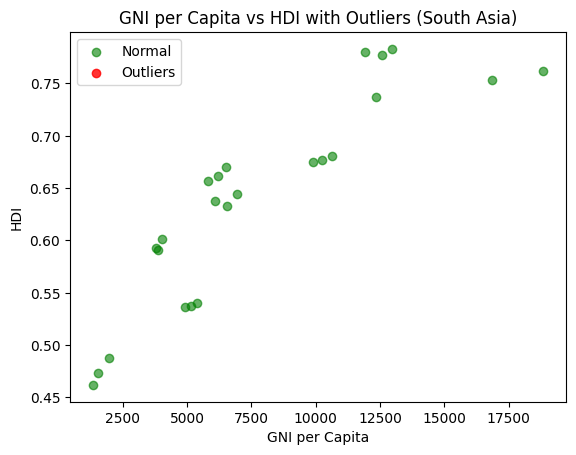

In [73]:
# Select rows that are NOT outliers in HDI or GNI
normal = hdi_southasia_df[~(hdi_southasia_df['HDI_Outlier'] | hdi_southasia_df['GNI_Outlier'])]
plt.scatter(normal['gross_inc_percap'], normal['hdi'], color='green', alpha=0.6, label='Normal')
# Select rows that ARE outliers in HDI or GNI
outliers = hdi_southasia_df[hdi_southasia_df['HDI_Outlier'] | hdi_southasia_df['GNI_Outlier']]
plt.scatter(outliers['gross_inc_percap'], outliers['hdi'], color='red', alpha=0.8, label='Outliers')

plt.xlabel('GNI per Capita')
plt.ylabel('HDI')
plt.title('GNI per Capita vs HDI with Outliers (South Asia)')
plt.legend()
plt.show()

In [74]:
# Display the outlier rows with selected columns: country, year, HDI, and GNI per capita
outliers[['country', 'year', 'hdi', 'gross_inc_percap']]

,country,year,hdi,gross_inc_percap


In [76]:
hdi_southasia_df.loc[:, 'gender_development'] = pd.to_numeric(
hdi_southasia_df['gender_development'], errors='coerce'
)

hdi_southasia_df.loc[:, 'life_expectancy'] = pd.to_numeric(
    hdi_southasia_df['life_expectancy'], errors='coerce'
)

hdi_southasia_df.loc[:, 'hdi'] = pd.to_numeric(
    hdi_southasia_df['hdi'], errors='coerce'
)

In [77]:
hdi_clean = hdi_southasia_df.dropna(subset=['gender_development', 'life_expectancy', 'hdi'])

In [78]:
corr_gender = hdi_clean['gender_development'].corr(hdi_clean['hdi'])
corr_life = hdi_clean['life_expectancy'].corr(hdi_clean['hdi'])

print("Pearson correlation between Gender Development Index and HDI:", corr_gender)
print("Pearson correlation between Life Expectancy Index and HDI:", corr_life)

Pearson correlation between Gender Development Index and HDI: 0.8742177004831327
Pearson correlation between Life Expectancy Index and HDI: 0.9387641385416623


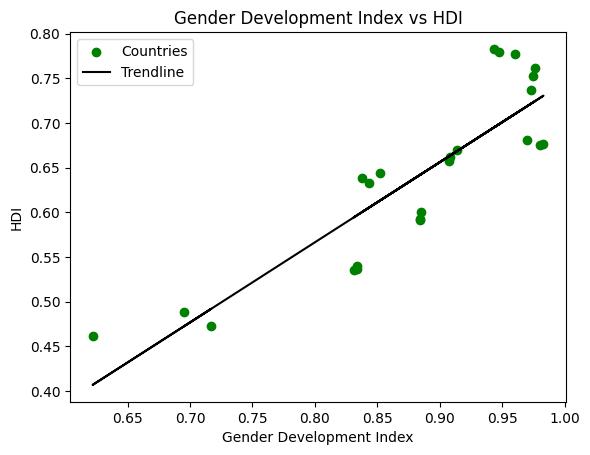

In [79]:
x = hdi_clean['gender_development']
y = hdi_clean['hdi']
plt.scatter(x, y, color='green', label='Countries')
m, c = np.polyfit(x, y, 1)
# Fit a linear trendline (y = m*x + c) using numpy's polyfit
plt.plot(x, m*x + c, color='black', label='Trendline')
plt.title('Gender Development Index vs HDI')
plt.xlabel('Gender Development Index')
plt.ylabel('HDI')
plt.legend()
plt.show()

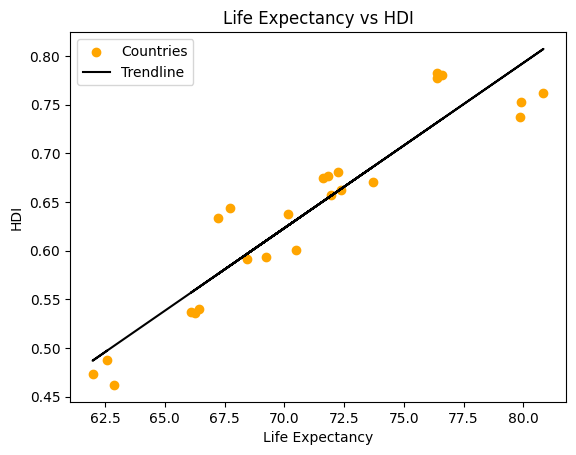

In [80]:
x2 = hdi_clean['life_expectancy']
y2 = hdi_clean['hdi']
plt.scatter(x2, y2, color='orange', label='Countries')
m2, c2 = np.polyfit(x2, y2, 1)
# Fit a linear trendline (y = m*x + c) using numpy's polyfit
plt.plot(x2, m2*x2 + c2, color='black', label='Trendline')
plt.title('Life Expectancy vs HDI')
plt.xlabel('Life Expectancy')
plt.ylabel('HDI')
plt.legend()
plt.show()

In [81]:
hdi_southasia_df.loc[:, 'gross_inc_percap'] = pd.to_numeric(
    hdi_southasia_df['gross_inc_percap'], errors='coerce'
)
hdi_southasia_df.loc[:, 'hdi'] = pd.to_numeric(
    hdi_southasia_df['hdi'], errors='coerce'
)

In [82]:
hdi_southasia_clean = hdi_southasia_df.dropna(subset=['gross_inc_percap', 'hdi'])
southasia_country = (
    hdi_southasia_clean
    .groupby('country', as_index=False)
    .agg({'gross_inc_percap':'mean', 'hdi':'mean'})
)

In [83]:
southasia_country['GNI_HDI_Gap'] = southasia_country['gross_inc_percap'] - southasia_country['hdi']

In [84]:
top_positive_gap = southasia_country.sort_values(
    by='GNI_HDI_Gap', ascending=False
).head(3)

print(top_positive_gap[['country', 'GNI_HDI_Gap']])

     country   GNI_HDI_Gap
4   Maldives  16011.230657
7  Sri Lanka  12481.929060
2     Bhutan  10253.395723


In [85]:
top_negative_gap = southasia_country.sort_values(
    by='GNI_HDI_Gap', ascending=True
).head(3)

print(top_negative_gap[['country', 'GNI_HDI_Gap']])

       country  GNI_HDI_Gap
0  Afghanistan  1618.240627
5        Nepal  3901.138692
6     Pakistan  5149.963106


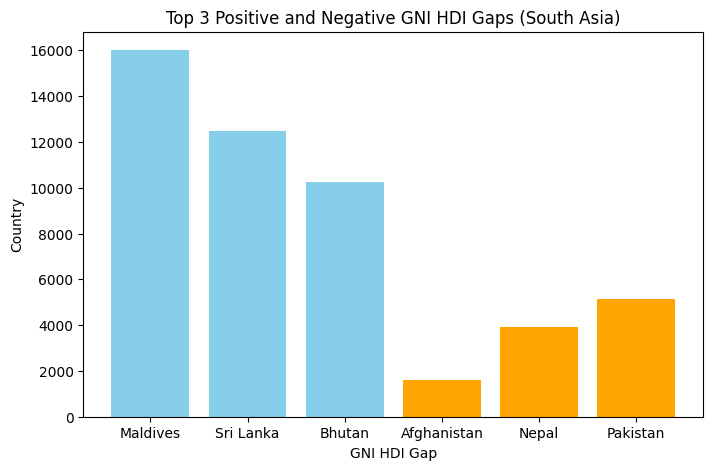

In [86]:
gap_plot = pd.concat([top_positive_gap, top_negative_gap])
colors = ['skyblue']*3 + ['orange']*3
plt.figure(figsize=(8,5))
plt.bar(gap_plot['country'], gap_plot['GNI_HDI_Gap'], color=colors)
plt.xlabel('GNI HDI Gap')
plt.ylabel('Country')
plt.title('Top 3 Positive and Negative GNI HDI Gaps (South Asia)')
plt.show()

In [87]:
print(gap_plot[['country', 'GNI_HDI_Gap']])

       country   GNI_HDI_Gap
4     Maldives  16011.230657
7    Sri Lanka  12481.929060
2       Bhutan  10253.395723
0  Afghanistan   1618.240627
5        Nepal   3901.138692
6     Pakistan   5149.963106


# Problem 3 Comparative Regional Analysis: South Asia vs Middle East

In [88]:
hdi_problem1B_df = pd.read_csv("HDI_problem1B.csv")

In [89]:
south_asia_countries = ["Afghanistan", "Bangladesh", "Bhutan", "India",
                        "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

middle_east_countries = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan",
                         "Kuwait", "Lebanon", "Oman", "Palestine", "Qatar",
                         "Saudi Arabia", "Syria", "United Arab Emirates", "Yemen"]

In [90]:
hdi_southasia_df = hdi_problem1B_df[hdi_problem1B_df['country'].isin(south_asia_countries)]

hdi_middleeast_df = hdi_problem1B_df[hdi_problem1B_df['country'].isin(middle_east_countries)]

In [91]:
hdi_southasia_df.to_csv("HDI_SouthAsia_2020_2022.csv", index=False)
hdi_middleeast_df.to_csv("HDI_MiddleEast_2020_2022.csv", index=False)

In [92]:
hdi_southasia_df = pd.read_csv("HDI_SouthAsia_2020_2022.csv")
hdi_middleeast_df = pd.read_csv("HDI_MiddleEast_2020_2022.csv")

In [93]:
hdi_southasia_df['hdi'] = pd.to_numeric(hdi_southasia_df['hdi'], errors='coerce')
hdi_middleeast_df['hdi'] = pd.to_numeric(hdi_middleeast_df['hdi'], errors='coerce')

In [94]:
hdi_southasia_df = hdi_southasia_df.dropna(subset=['hdi'])
hdi_middleeast_df = hdi_middleeast_df.dropna(subset=['hdi'])

In [95]:
southasia_agg = hdi_southasia_df.groupby('country', as_index=False)['hdi'].mean()
middleeast_agg = hdi_middleeast_df.groupby('country', as_index=False)['hdi'].mean()

# Compute mean and std dev for descriptive stats
mean_southasia = southasia_agg['hdi'].mean()
std_southasia = southasia_agg['hdi'].std()
mean_middleeast = middleeast_agg['hdi'].mean()
std_middleeast = middleeast_agg['hdi'].std()

print("South Asia HDI (2020-2022) Mean:", round(mean_southasia, 3), ", Std Dev:", round(std_southasia, 3))
print("Middle East HDI (2020-2022) Mean:", round(mean_middleeast, 3), ", Std Dev:", round(std_middleeast, 3))

South Asia HDI (2020-2022) Mean: 0.64 , Std Dev: 0.103
Middle East HDI (2020-2022) Mean: 0.789 , Std Dev: 0.146


In [96]:
# Top 3 and bottom 3 countries per region
top3_southasia = southasia_agg.nlargest(3, 'hdi')
bottom3_southasia = southasia_agg.nsmallest(3, 'hdi')

top3_middleeast = middleeast_agg.nlargest(3, 'hdi')
bottom3_middleeast = middleeast_agg.nsmallest(3, 'hdi')

In [97]:
# Add region column for plotting
top3_southasia['Region'] = 'South Asia'
bottom3_southasia['Region'] = 'South Asia'
top3_middleeast['Region'] = 'Middle East'
bottom3_middleeast['Region'] = 'Middle East'

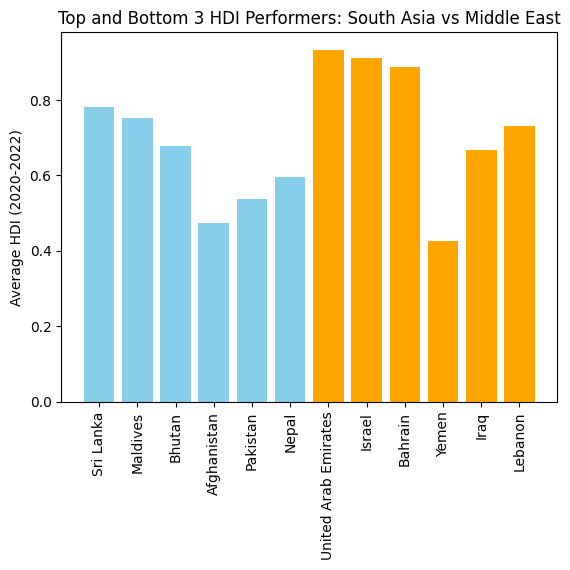

In [98]:
plot_df = pd.concat([top3_southasia, bottom3_southasia, top3_middleeast, bottom3_middleeast])
# Assign colors: green for South Asia, red for Middle East
colors = ['skyblue' if r == 'South Asia' else 'orange' for r in plot_df['Region']]
# Simple bar chart
plt.bar(plot_df['country'], plot_df['hdi'], color=colors)
plt.ylabel('Average HDI (2020-2022)')
plt.title('Top and Bottom 3 HDI Performers: South Asia vs Middle East')
# Rotate country names vertically
plt.xticks(rotation=90)
plt.show()

In [99]:
metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']
# Convert the metrics to numeric values
for metric in metrics:
    hdi_southasia_df[metric] = pd.to_numeric(hdi_southasia_df[metric], errors='coerce')
    hdi_middleeast_df[metric] = pd.to_numeric(hdi_middleeast_df[metric], errors='coerce')
# Remove rows with missing values in any of the metrics for South Asia
hdi_southasia_clean = hdi_southasia_df.dropna(subset=metrics)
# Remove rows with missing values in any of the metrics for Middle East
hdi_middleeast_clean = hdi_middleeast_df.dropna(subset=metrics)

In [100]:
avg_southasia = hdi_southasia_clean[metrics].mean()
avg_middleeast = hdi_middleeast_clean[metrics].mean()
comparison_df = pd.DataFrame({
    'Metric': metrics,
    'South Asia': avg_southasia.values,
    'Middle East': avg_middleeast.values
})
print(comparison_df)

               Metric   South Asia   Middle East
0  gender_development     0.881458      0.896545
1     life_expectancy    70.970083     75.855455
2    gross_inc_percap  7766.509931  37750.770520


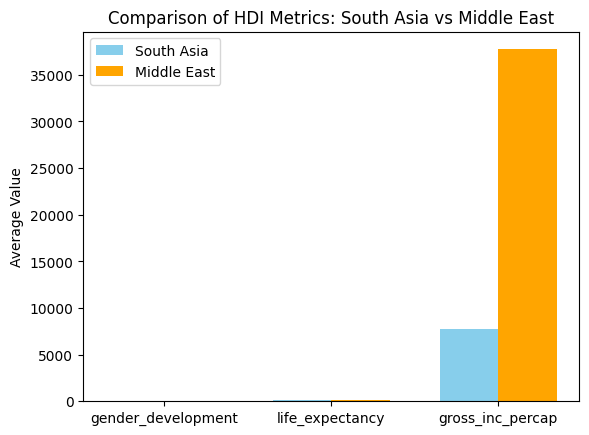

In [101]:
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, comparison_df['South Asia'], width, label='South Asia', color='skyblue')
plt.bar(x + width/2, comparison_df['Middle East'], width, label='Middle East', color='orange')
plt.xticks(x, comparison_df['Metric'])
plt.ylabel('Average Value')
plt.title('Comparison of HDI Metrics: South Asia vs Middle East')
plt.legend()
plt.show()

In [102]:
range_southasia = hdi_southasia_df['hdi'].max() - hdi_southasia_df['hdi'].min()
range_middleeast = hdi_middleeast_df['hdi'].max() - hdi_middleeast_df['hdi'].min()
# Print the HDI range rounded to 3 decimal places
print("South Asia HDI Range:", round(range_southasia, 3))
print("Middle East HDI Range:", round(range_middleeast, 3))

South Asia HDI Range: 0.321
Middle East HDI Range: 0.513


In [103]:
cv_southasia = hdi_southasia_df['hdi'].std() / hdi_southasia_df['hdi'].mean()
cv_middleeast = hdi_middleeast_df['hdi'].std() / hdi_middleeast_df['hdi'].mean()
print("South Asia CV:", round(cv_southasia, 3))
print("Middle East CV:", round(cv_middleeast, 3))

South Asia CV: 0.154
Middle East CV: 0.179


In [104]:
if cv_southasia > cv_middleeast:
    print("South Asia shows more variation in HDI.")
else:
    print("Middle East shows more variation in HDI.")

Middle East shows more variation in HDI.


In [105]:
corr_sa_gender = hdi_southasia_clean['gender_development'].corr(
    hdi_southasia_clean['hdi']
)

corr_sa_life = hdi_southasia_clean['life_expectancy'].corr(
    hdi_southasia_clean['hdi']
)

print("South Asia:")
print("Gender Development vs HDI:", round(corr_sa_gender, 3))
print("Life Expectancy vs HDI:", round(corr_sa_life, 3))

South Asia:
Gender Development vs HDI: 0.874
Life Expectancy vs HDI: 0.939


In [106]:
corr_me_gender = hdi_middleeast_clean['gender_development'].corr(
    hdi_middleeast_clean['hdi']
)

corr_me_life = hdi_middleeast_clean['life_expectancy'].corr(
    hdi_middleeast_clean['hdi']
)

print("Middle East:")
print("Gender Development vs HDI:", round(corr_me_gender, 3))
print("Life Expectancy vs HDI:", round(corr_me_life, 3))

Middle East:
Gender Development vs HDI: 0.936
Life Expectancy vs HDI: 0.933


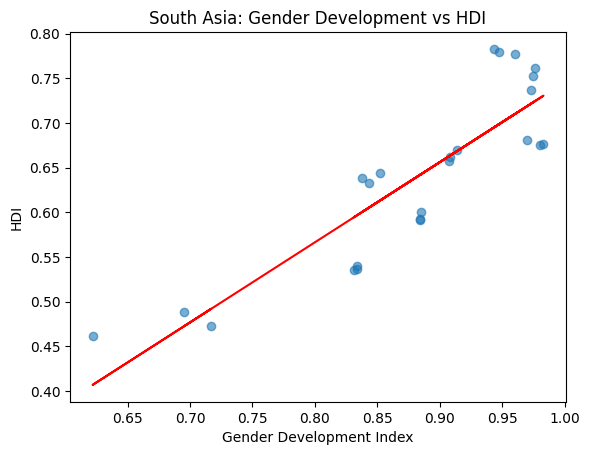

In [107]:
x = hdi_southasia_clean['gender_development']
y = hdi_southasia_clean['hdi']

plt.scatter(x, y, alpha=0.6)
m, c = np.polyfit(x, y, 1)
plt.plot(x, m*x + c, color='red')

plt.xlabel("Gender Development Index")
plt.ylabel("HDI")
plt.title("South Asia: Gender Development vs HDI")
plt.show()

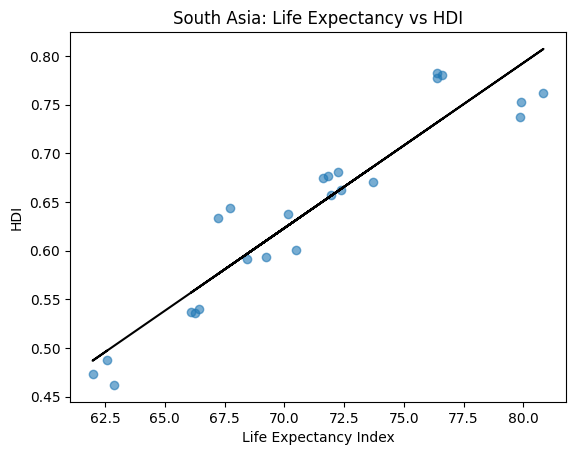

In [108]:
x = hdi_southasia_clean['life_expectancy']
y = hdi_southasia_clean['hdi']

plt.scatter(x, y, alpha=0.6)
# Fit a linear trendline (y = m*x + b) using numpy's polyfit
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='black')

plt.xlabel("Life Expectancy Index")
plt.ylabel("HDI")
plt.title("South Asia: Life Expectancy vs HDI")
plt.show()

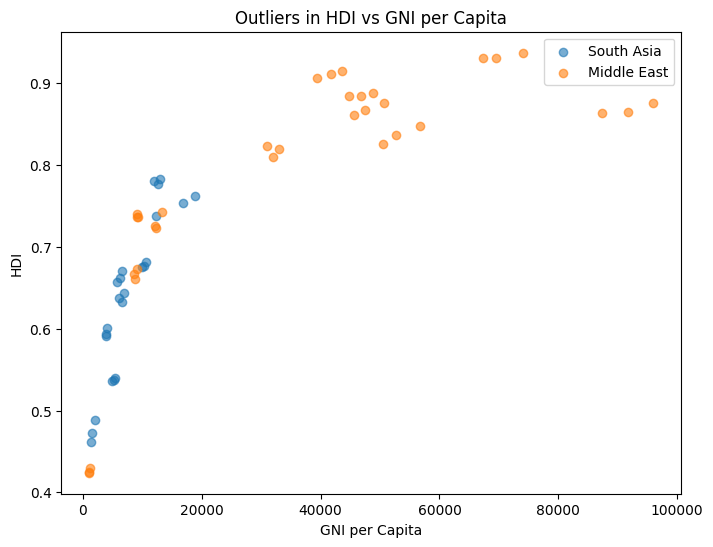

In [109]:
# 3.9 Task 7: Outlier Detection Using 1.5 × IQR Rule
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)

# Flag outliers in HDI or GNI per Capita for each region
hdi_southasia_df['Outlier'] = detect_outliers(hdi_southasia_df['hdi']) | \
                               detect_outliers(hdi_southasia_df['gross_inc_percap'])

hdi_middleeast_df['Outlier'] = detect_outliers(hdi_middleeast_df['hdi']) | \
                               detect_outliers(hdi_middleeast_df['gross_inc_percap'])

# Scatter plot highlighting all points (outliers will be flagged separately)
plt.figure(figsize=(8,6))
plt.scatter(hdi_southasia_df['gross_inc_percap'], hdi_southasia_df['hdi'],
            label="South Asia", alpha=0.6)
plt.scatter(hdi_middleeast_df['gross_inc_percap'], hdi_middleeast_df['hdi'],
            label="Middle East", alpha=0.6)

plt.xlabel("GNI per Capita")
plt.ylabel("HDI")
plt.title("Outliers in HDI vs GNI per Capita")
plt.legend()
plt.show()